Customer Churn dataset Shape:(2000, 17)

Datatypes in dataset:
customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Target Variable Description:
The target variable in this dataset is 'churn', which indicates whether a customer left the service.
0 represents customers who were retained.
1 represents customers who churned.

Count of Missing Values in Datase

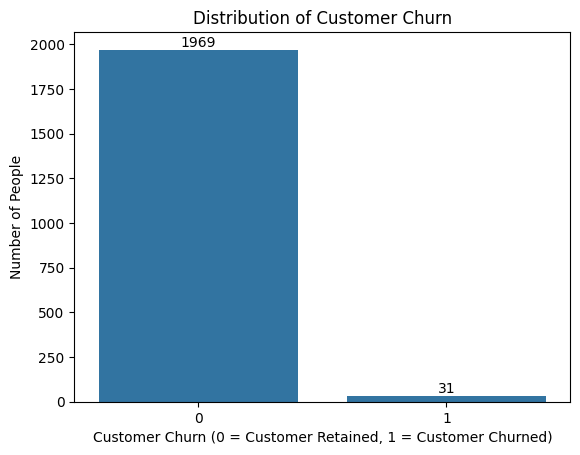

In [1]:
# Part 1: Neural Network Fundamentals and Training Behavior Analysis

## Task 1: Dataset Understanding

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the raw dataset

customer_churn = pd.read_csv('part_1_neural_network_analysis/customer_churn_nn.csv')

### Number of rows and columns
print(f'Customer Churn dataset Shape:{customer_churn.shape}')

### Type of input features
print(f'\nDatatypes in dataset:\n{customer_churn.dtypes}')
print("\nTarget Variable Description:")

### Target Variable Description
print("The target variable in this dataset is 'churn', which indicates whether a customer left the service.")
print("0 represents customers who were retained.")
print("1 represents customers who churned.")

### Missing value check
missing_values = customer_churn.isnull().sum()
print(f'\nCount of Missing Values in Dataset:\n{missing_values}')

### Basic statistical summary
print(f'\nBasic Statistical Summary of the Dataset:\n{customer_churn.describe()}')

#### Distribution of the target variable
print("\nTarget Class Distribution Plot: Distribution of Customers With and Without Churn\n")
ax = sns.countplot(x='churn', data=customer_churn)
# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Customer Churn (0 = Customer Retained, 1 = Customer Churned)")
plt.ylabel("Number of People")
plt.title("Distribution of Customer Churn")
plt.show()

In [2]:
## Task 2: Data Preprocessing

from sklearn.preprocessing import OneHotEncoder

### Handling Missing Values
if missing_values.sum() == 0:
    print('\nThere are no missing values in the dataset.')

else:
    print('\nMissing Values in the Dataset:\n')
    print(missing_values[missing_values > 0])

### Encoding categorical columns

categorical_cols = ['region','plan_type','contract_type','payment_method']
numerical_cols = customer_churn.select_dtypes(include ='number').columns

# --Creating encoder
encoder = OneHotEncoder(drop='first', sparse_output = False)

# --Fitting & transforming all columns
encoded = encoder.fit_transform(customer_churn[categorical_cols])

# --Getting column names
new_col_names = encoder.get_feature_names_out(categorical_cols)
print(f'\nNew Columns for the dataset are: \n{new_col_names}')

# --Converting to DataFrame
encoded_df = pd.DataFrame(encoded, columns=new_col_names)

# --Aligning index
encoded_df.index = customer_churn.index

# --Dropping original columns and merge
print(f'\n Original Dataset: \n{customer_churn.head()}')
customer_churn = customer_churn.drop(categorical_cols, axis=1)
print(f'\n Dataset after droping categorical columns: \n{customer_churn.head()}')
customer_churn = pd.concat([customer_churn, encoded_df], axis=1)

pd.set_option('display.max_columns', None)
print(f'\n Dataset after adding new columns: \n{customer_churn.head()}')

### Scaling numerical features using StandardScaler

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_cols = numerical_cols.drop('churn')
customer_churn[numerical_cols] = scaler.fit_transform(customer_churn[numerical_cols])
customer_churn = customer_churn.drop('customer_id', axis=1)
customer_churn.describe()



### Splitting the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X = customer_churn.drop(['churn'], axis=1)  # Input Features
y = customer_churn['churn']                 # Target Variable

print("\nFeatures (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)





There are no missing values in the dataset.

New Columns for the dataset are: 
['region_East' 'region_North' 'region_South' 'region_West'
 'plan_type_Enterprise' 'plan_type_Premium' 'plan_type_Standard'
 'contract_type_One-year' 'contract_type_Two-year'
 'payment_method_Debit Card' 'payment_method_Net Banking'
 'payment_method_UPI' 'payment_method_Wallet']

 Original Dataset: 
  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             7

In [3]:
## Task 3: Neural Network Model Building

### Importing Neural Network Libarary
import tensorflow as tf

### Initialize the neural network model
model = tf.keras.Sequential([
    
    # ---Adding Input Layer
    tf.keras.Input(shape=(X_train.shape[1],)),
    
    # ---Adding First Hidden Layer
    tf.keras.layers.Dense(
        units=16,                               # 16 neurons
        activation='relu'                       # Activation Function ='relu' helps learn non-linear patterns
    ),
    
    # ---Adding Second Hidden Layer
    tf.keras.layers.Dense(
        units=8,                                # 8 neurons
        activation='relu'                       # Activation Function ='relu' helps learn non-linear patterns
    ),
    
    # ---Adding output layer
    tf.keras.layers.Dense(
        units=1,                                # 1 neuron in output layer becasue target variable is binary (0=Retained, 1 = Churn)
        activation='sigmoid'                    # Activation Function = 'sigmoid' gives output between 0 and 1
    )
])


### Compiling the Model

model.compile(
    optimizer='adam',                   # Optimizer
    loss='binary_crossentropy',         # Loss Function
    metrics=['accuracy']
)


### Displaying Model Summary

print("\nNeural Network Model Summary:\n")
model.summary()




Neural Network Model Summary:



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
## Task 4: Training and Evaluation


####  Training the Neural Network Model

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

### Evaluating Model Performance on Training Data
train_loss, train_accuracy = model.evaluate(X_train, y_train)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"\nTraining Loss: {train_loss:.4f}")


### Evaluating Model Performance on Testing Data

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"\nTesting Loss: {test_loss:.4f}")


### Generating Predictions

y_pred_prob = model.predict(X_test)

### Converting probabilities into binary values
y_pred = (y_pred_prob > 0.5).astype(int)


### Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)


### Saving Evaluation Outputs Figure

fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax
)

ax.set_xlabel("Predicted Customer Churn")
ax.set_ylabel("Actual Customer Churn")
ax.set_title("Confusion Matrix for Customer Churn Prediction")

# Save figure
plt.savefig(
    'evaluation_outputs.png',
    bbox_inches='tight'
)

plt.close()

print("\nevaluation_outputs.png has been saved successfully.")

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4820 - loss: 0.7433 - val_accuracy: 0.7937 - val_loss: 0.5944
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9203 - loss: 0.4849 - val_accuracy: 0.9844 - val_loss: 0.3986
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9797 - loss: 0.3156 - val_accuracy: 0.9937 - val_loss: 0.2393
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.1927 - val_accuracy: 0.9937 - val_loss: 0.1358
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.1302 - val_accuracy: 0.9937 - val_loss: 0.0881
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.1060 - val_accuracy: 0.9937 - val_loss: 0.0654
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0954 - val_accuracy: 0.9937 - val_loss: 0.0546
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0902 - val_accuracy: 0.9937 - val_loss:

Interpretation:
The confusion matrix shows that the model correctly classified 394 non-churned customers.
However, the model failed to correctly identify any churned customers.
There were 6 churned customers that were incorrectly classified as non-churned.
This indicates that the model is biased toward predicting the majority class (non-churn) and is not effectively detecting customer churn.

In [6]:
## Task 5: Hyperparameter Experimentation

# =====================================================
# Experiment 1
# =====================================================

model_1 = tf.keras.Sequential([

    tf.keras.Input(shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(16, activation='relu'),

    tf.keras.layers.Dense(8, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_1 = model_1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss_1, accuracy_1 = model_1.evaluate(X_test, y_test, verbose=0)

# =====================================================
# Experiment 2
# Changed:
# - More neurons
# - More epochs
# =====================================================

model_2 = tf.keras.Sequential([

    tf.keras.Input(shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(16, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_2 = model_2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss_2, accuracy_2 = model_2.evaluate(X_test, y_test, verbose=0)

# =====================================================
# Experiment 3
# Changed:
# - Learning Rate
# - Batch Size
# =====================================================

# Create Adam optimizer with different learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_3 = tf.keras.Sequential([

    tf.keras.Input(shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(16, activation='relu'),

    tf.keras.layers.Dense(8, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_3.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_3 = model_3.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

loss_3, accuracy_3 = model_3.evaluate(X_test, y_test, verbose=0)


### Comparison Table


import pandas as pd

comparison_table = pd.DataFrame({

    'Experiment': [
        'Experiment 1',
        'Experiment 2',
        'Experiment 3'
    ],

    'Hidden Layers/Neurons': [
        '16, 8',
        '32, 16',
        '16, 8'
    ],

    'Learning Rate': [
        'Default Adam',
        'Default Adam',
        '0.001'
    ],

    'Batch Size': [
        32,
        32,
        64
    ],

    'Epochs': [
        20,
        30,
        20
    ],

    'Test Loss': [
        round(loss_1, 4),
        round(loss_2, 4),
        round(loss_3, 4)
    ],

    'Test Accuracy': [
        round(accuracy_1, 4),
        round(accuracy_2, 4),
        round(accuracy_3, 4)
    ]
})


### Display Comparison Table

# =====================================================
# Save Model Comparison Table as CSV
# =====================================================

comparison_table.to_csv(
    'model_comparison_table.csv',
    index=False
)

print("\nmodel_comparison_table.csv has been saved successfully.")



model_comparison_table.csv has been saved successfully.


Interpretation:

- Three neural network experiments were conducted by changing the number of neurons, learning rate, batch size, and epochs.

- Experiment 2 achieved the highest test accuracy (98.75%), indicating slightly better prediction performance compared to the other experiments. Increasing the number of neurons and training epochs helped improve the model accuracy.

- Experiment 1 produced the lowest test loss (0.0583), suggesting more stable and confident predictions while maintaining high accuracy.

- Experiment 3 used a different learning rate and larger batch size, but its performance was slightly lower compared to Experiment 2.

- Overall, Experiment 2 can be considered the best-performing model based on accuracy, while Experiment 1 achieved the lowest prediction error.

Task 6: FINAL REFLECTION:
-----------------

* Role of Weights and Biases

Weights and biases help the neural network learn patterns from the data.
Weights determine the importance of each input feature, while biases help adjust the output of neurons to improve predictions. During training, the model continuously updates these values to reduce prediction errors.


* Why an Activation Function is Required

Activation functions help the neural network learn complex and non-linear relationships in the data. Without activation functions, the neural network would behave like a simple linear model and would not be able to learn complicated patterns effectively.

* What Happens When Learning Rate is Too High or Too Low

If the learning rate is too high, the model may learn too quickly and miss the optimal solution, causing unstable performance.
If the learning rate is too low, the model learns very slowly and may take a long time to reach good performance.

* Underfitting or Overfitting in the Model

The model did not show major signs of underfitting or overfitting. Training and testing performance were both high and consistent, indicating that the model generalized well to unseen data.